# Digital Biomarkers Project

The goal of this project is to develop a pipeline for analyzing breast ultrasound images, extracting meaningful features, and classifying tumors into benign or malignant categories. By leveraging medical imaging, feature extraction, and machine learning, the project demonstrates the practical applications of digital biomarkers in personalized healthcare.

Tasks:

- Data Preparation: Organizing ultrasound images and masks for analysis.
- Feature Extraction: Deriving numerical descriptors of tumor properties.
- Classification: Using machine learning to predict tumor type based on extracted features.

# Step 1: Data Preparation
The first step is to prepare a clean, structured dataset of benign and malignant tumor images and segmentation masks.

For this, I download the dataset, try to understand its structure, and preprocessing it for analysis. Using the csv provided, I read the image into four lists: benignant, malignant and the  corresponding segmentation mask, which identifies the tumor's location within the ultrasound image. 
The images are visualized to ensure correctness and alignment between the ultrasound image and its mask.

## Imports

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
from PIL import Image
from typing import List, Tuple
from skimage.feature import graycomatrix, graycoprops
from tpot import TPOTClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

## Loading the images
I will perform the following steps to load the images:
1. Paths: Define the paths to the benign, malignant, and normal folders
2. Initialize empty lists to store images and labels
3. Define a function to load the images and labels

### 1. Paths
In the first step, I save the paths to the folders containing the different datasets to variables so I can use them later on.

In [2]:
base_dir = "../../Breast tumor/Dataset_BUSI_with_GT"
benign_dir = os.path.join(base_dir, "benign")
malignant_dir = os.path.join(base_dir, "malignant")
normal_dir = os.path.join(base_dir, "normal")

Then, I load the valid indices from the csv file. This file contains the indices of images and masks that are considered valid. Some are not, this seems to be due to text / other distractors that could interfere with the feature extraction. 

In [3]:
valid_indices_df = pd.read_csv('../../Breast tumor/Benign_malignant_indices.csv')

benign_indices = valid_indices_df['benign'].dropna().astype(int).tolist()
malignant_indices = valid_indices_df['malignant'].dropna().astype(int).tolist()

During initial analysis of the images, I realised we have images that contain several breast tumours in one image. This was visible because I tried to import all masks and images and I had one more mask than images (of the benign images kind). It was image 181 and I ended up taking it out of the project.

### 2. Define a function to load the images and labels
With this function, I can load the images into the lists. We pass the category benign / malignant as an argument so we can use it to load both. The function returns two lists: the images and the corresponding masks.

Problems / Goals:
- seperate images and masks
- make sure only valid images are loaded (see the csv)
- later edit: make sure we have the same amount of masks and images. & only include images we want to keep -> in the valid list of benign images, there was the image 181 included, which contained several tumours/several masks. I assumed this was something we wanted to exclude and removed the image 181 and it's mask.

In [4]:
exclude_benign = [181]
benign_indices = [index for index in benign_indices if index not in exclude_benign]

In [5]:
def read_images(folder_path, category, valid_indices) -> Tuple[List[str], List[str]]:
    images = []
    masks = []

    for index in valid_indices:
            # Construct the filenames based on the index and category
            img_file_name = f"{category} ({index}).png"
            mask_file_name = f"{category} ({index})_mask.png"

            # Define the full file paths
            img_file_path = os.path.join(folder_path, img_file_name)
            mask_file_path = os.path.join(folder_path, mask_file_name)
            # Check if the files exist
            if not os.path.exists(img_file_path) or not os.path.exists(mask_file_path):
                raise FileNotFoundError(f"Image or mask file missing for index {index}")

            # Read the image and mask, and append them to the lists
            images.append(plt.imread(img_file_path)[:, :, 0])
            masks.append(plt.imread(mask_file_path))


    return images, masks


Here we call the function for both benign and malignant images.

In [6]:
benign_images, benign_masks = read_images(benign_dir, 'benign', benign_indices)
malignant_images, malignant_masks = read_images(malignant_dir, 'malignant', malignant_indices)

### 3. Check whether Images are correctly loaded
To verify the previous steps, I display the first item in each list.

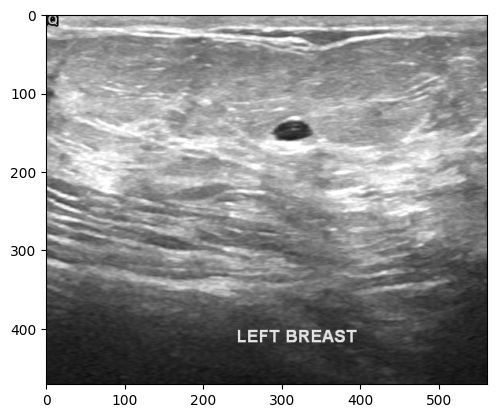

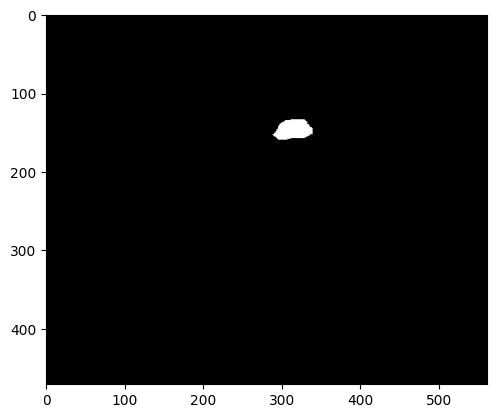

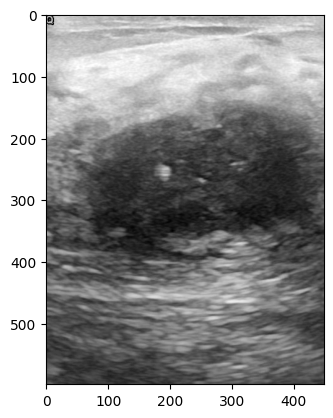

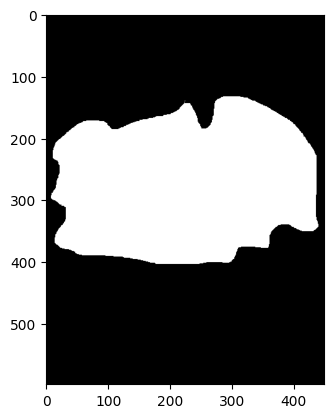

In [7]:
plt.figure()
plt.imshow(benign_images[0], cmap = "gray")
plt.figure()
plt.imshow(benign_masks[0], cmap = "gray")
plt.figure()
plt.imshow(malignant_images[0], cmap = "gray")
plt.figure()
plt.imshow(malignant_masks[0], cmap = "gray")

I also want to make sure I only loaded valid images. To do this, I compare the length of the valid indices benign / malignant with the length of the image lists.

In [8]:
print(len(valid_indices_df['benign']))
print(len(benign_images))
print(len(benign_masks))
print(len(valid_indices_df['malignant']))
print(len(malignant_images))
print(len(malignant_masks))

176
175
175
176
176
176


Here we can see that I now have one less image for the benign images (as I removed the one with the two tumours / masks). If necessary, I will later drop out one of the malignant images at random.

# Part 2: Feature Extraction
In this part, I try to extract science-based features from the images / masks.

## Shape Features
I try to extract the following features from the images:
- Area (Volume): number of pixels within tumor 
- Perimeter: this expresses the total surface of the tumor
- Circularity: round vs. irregular shaped?
- Regularity: how irregular is the "border" of the tumor

To calculate these geometric features, we can use the masks (and don't need the images themselves.)

### Area
The area describes the number of pixels contained in the tumor / mask. So we can return the sum of all values in the mask that are > 0.

In [9]:
def calculate_area(mask):
    return np.sum(mask > 0)


### Perimeter
Here, I calculate the boundary of the mask to get the surface of the tumor. 

In [10]:
def calculate_perimeter(mask):
    #to boolean array
    mask = mask > 0
    # Compute the boundary (edges) of the mask
    boundary = np.logical_xor(mask, np.pad(mask[:-1, :], ((1, 0), (0, 0)), mode='constant')) | \
               np.logical_xor(mask, np.pad(mask[:, :-1], ((0, 0), (1, 0)), mode='constant'))
    return np.sum(boundary)


### Circularity
Here we calculate the circularity of the tumor by comparing the tumor's area and perimeter. 
We compare the shape of our tumor to the perfect circle, because the perfect circle would have the smallest perimeter for a given area.
There is a formula to express this: 
Circularity = (4 * pi * area) / (perimeter^2)

The circularity of a perfect circle would be 1. The closer to one the circularity of our tumour is, the closer to a perfect circle (= the more round) it is.

In [11]:
def calculate_circularity(area, perimeter):
    if perimeter == 0: # this is to avoid dividing by zero
        return 0
    return (4 * np.pi * area) / (perimeter ** 2)

### Regularity
Here, we calculate how irregular the "border" of our tumour is. We do this by comparing the area of the tumor to the area of the smallest rectangle that fully surrounds the tumor (= bounding box). 
This also results in a value between 0 (very irregular) and 1 (very rectangular, fills the bounding box).

In [12]:
def calculate_regularity(mask):
    mask = mask > 0
    rows = np.any(mask, axis=1) # returns True for rows that contain at least one "True" value = one part of tumour => sum of all these rows= height of tumour
    cols = np.any(mask, axis=0) # see above but for width
    bounding_box_area = (rows.sum() * cols.sum()) # height * width = area of smallest rectangle that can contain the tumour
    if bounding_box_area == 0: # to avoid dividing by zero (would be an empty mask)
        return 0
    return np.sum(mask) / bounding_box_area

### Shape Feature Extraction
Next, I define a function that runs the 4 previously defined functions and creates a df with the results.

In [13]:
def extract_shape_features(masks):
    areas = []
    perimeters = []
    circularities = []
    regularities = []

    for mask in masks:
        area = calculate_area(mask)
        perimeter = calculate_perimeter(mask)
        circularity = calculate_circularity(area, perimeter)
        regularity = calculate_regularity(mask)

        areas.append(area)
        perimeters.append(perimeter)
        circularities.append(circularity)
        regularities.append(regularity)

    df = pd.DataFrame({
        'area': areas,
        'perimeter': perimeters,
        'circularity': circularities,
        'regularity': regularities
    })

    return df

In [14]:
benign_df = extract_shape_features(benign_masks)
malignant_df = extract_shape_features(malignant_masks)

## Texture Features

I will extract the following features:
From the image:
- Mean Intensity: Average brightness
- Standard Deviation: Intensity variability or spread

From the Gray-Level Co-Occurrence Matrix (GLCM):



I am using the graycomatrix function from the skimage (Scikit-Image) library to compute the GLCM.

### 1st Statistical Order

#### Mean Intensity
Computes the average intensity of the entire image. This indicates a baseline "brightness" or intensity of the image, with higher values indicating a brighter image.

In [15]:
def calculate_mean_intensity(image):
    return np.mean(image)

#### Standard Deviation
Measures the standard deviation of the grayscale values in the image. This gives us a feeling of the spread / variability of intensity values / gray scales contained in the image.

In [16]:
def calculate_standard_deviation(image):
    return np.std(image)

### 2nd Statistical Order
These features are computed using the Gray level co-occurrence matrix (GLCM). I use the graycomatrix function from the Scikit-Image library to compute it. Then, I compute different features from the matrix.

#### Contrast
Measures the difference in intensity between neighboring pixels as described by the gray-level co-occurrence matrix (GLCM).

Higher values mean that the contrast / transition is higher and sharper, while low values indicate smooth / uniformer texture.

In [17]:
def calculate_contrast(glcm):
    return graycoprops(glcm, 'contrast')[0, 0]

#### Homogeneity
This measures, how "smooth" or "similar" a texture is.
High homogeneity indicates a smooth texture with minimal intensity variation. Low homogeneity suggests irregular or abrupt intensity changes.

In [18]:
def calculate_homogeneity(glcm):
    return graycoprops(glcm, 'homogeneity')[0, 0]

#### Entropy
How random the intensity distribution is in the image.
High entropy indicates a diverse and irregular texture.
Low entropy suggests uniform or predictable patterns.

In [19]:
def calculate_entropy(glcm):
    glcm_normalized = glcm / glcm.sum()
    return -np.sum(glcm_normalized * np.log2(glcm_normalized + np.finfo(float).eps))


In [20]:
def extract_texture_features(images, df):
    contrasts = []
    homogeneities = []
    entropies = []
    mean_intensities = []
    standard_deviations = []

    for image in images:
        # Ensure image is grayscale with integer pixel values
        image = (image * 255).astype(np.uint8) if image.max() <= 1.0 else image

        # Calculate GLCM (Gray-Level Co-occurrence Matrix)
        glcm = graycomatrix(image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

        # Calculate texture features
        contrasts.append(calculate_contrast(glcm))
        homogeneities.append(calculate_homogeneity(glcm))
        entropies.append(calculate_entropy(glcm))

        # Calculate first-order statistics
        mean_intensities.append(calculate_mean_intensity(image))
        standard_deviations.append(calculate_standard_deviation(image))

    # Add texture features to DataFrame
    df['contrast'] = contrasts
    df['homogeneity'] = homogeneities
    df['entropy'] = entropies
    df['mean_intensity'] = mean_intensities
    df['standard_deviation'] = standard_deviations

    return df

In [21]:
benign_df = extract_texture_features(benign_images, benign_df)
malignant_df = extract_texture_features(malignant_images, malignant_df)

In [22]:
benign_df

,area,perimeter,circularity,regularity,contrast,homogeneity,entropy,mean_intensity,standard_deviation
0,984,134,0.688645,0.742081,64.395158,0.316986,11.610781,132.375146,58.393189
1,7022,344,0.745682,0.749253,66.870477,0.328587,11.605874,113.447975,59.422229
2,2204,201,0.685535,0.791667,13.868098,0.373782,11.125484,109.484471,51.444986
3,3997,249,0.810112,0.844853,11.243612,0.383332,10.996552,107.805602,50.616808
4,32918,711,0.818284,0.799505,17.427551,0.394447,11.140791,103.240733,58.324293
...,...,...,...,...,...,...,...,...,...
170,48810,1111,0.496925,0.751385,37.818330,0.314141,11.396986,93.711017,47.096793
171,6540,442,0.420671,0.552645,26.398586,0.331101,11.077159,121.147345,39.952289
172,1568,156,0.809668,0.845283,25.536443,0.373442,11.039448,76.919683,57.004296
173,59848,1140,0.578695,0.764147,63.367204,0.387222,10.639272,66.410608,48.420436


In [23]:
malignant_df

,area,perimeter,circularity,regularity,contrast,homogeneity,entropy,mean_intensity,standard_deviation
0,90995,1438,0.552980,0.777257,16.913652,0.337749,11.444798,118.212885,61.458348
1,13990,599,0.489975,0.608525,17.065868,0.351570,10.979863,99.250201,64.023955
2,11825,560,0.473844,0.572085,18.133965,0.351078,11.029857,98.869972,64.241594
3,12527,608,0.425843,0.633957,20.265584,0.333447,11.159910,95.867223,64.163793
4,10196,465,0.592562,0.646626,20.289069,0.341658,11.118117,97.411568,64.746687
...,...,...,...,...,...,...,...,...,...
171,145206,1657,0.664583,0.766242,17.913220,0.422405,10.863514,93.465675,60.348841
172,28227,742,0.644268,0.730512,34.969354,0.349150,11.218499,78.473940,51.910359
173,145369,1760,0.589734,0.708460,19.917587,0.560209,9.100394,44.635715,38.934657
174,5025,340,0.546246,0.690247,15.856217,0.379634,10.798285,71.007477,54.184064


# Part 3: Classification
The goal in this part is to train a classifier that predicts whether an image contains a benign or a malignant tumor.

For this, the following steps need to be taken:
- create a joint df out of benign_df and malignant_df
- split this df into train/test
- train ML models using CV

## Combining Dataframes

Here, I assign the two dataframes their labels that will be the target for our classification task.

In [24]:
benign_df['label'] = 0
malignant_df['label'] = 1

Next, I drop one random instance of the malignant_df (because we took out one instance of the benign_df due to it containing several tumours and having perfectly balanced classes seems better.)

Then I combine both into one df.

In [25]:
random_index = random.choice(malignant_df.index)
malignant_df = malignant_df.drop(random_index)

combined_df = pd.concat([benign_df, malignant_df], ignore_index=True)

## Train-Test Split
I decided to perform only a train-test split (rather than train val test split) and use cross-validation for model evaluation due to the limited availability of the data.

In [26]:
X = combined_df.drop('label', axis=1)
y = combined_df['label']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Training Different ML Models
Now, I try different kinds of machine learning with the dataset I created,
I always use 5-fold CV to get the most representative evaluation of the model (and be able to compare the different models!) with this relatively small dataset, as well as a hyperparameter grid to find the optimal hyperparameters of the model.

In [28]:
performance_logs = []

def log_model_performance(model_name, y_true, y_pred):
    global performance_logs
    
    # Calculate performance metrics
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    }
    
    # Append the metrics to the logs
    performance_logs.append(metrics)

In [29]:
def display_performance_comparison():
    global performance_logs
    performance_df = pd.DataFrame(performance_logs)
    performance_df = performance_df.sort_values(by='F1-Score', ascending=False)

    print("Model Performance Comparison:")
    print(performance_df)
    
    return performance_df

### Logistic Regression
First, I try logistic regression, a relatively simple model.
It achieves a best CV score of 0.82. This is not satisfactory.

In [30]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Define the hyperparameter grid
param_grid_log_reg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# Perform grid search with 5-fold CV
grid_log_reg = GridSearchCV(estimator=log_reg, param_grid=param_grid_log_reg, cv=5, scoring='accuracy')
grid_log_reg.fit(X_train, y_train)

# Best parameters and best score
print("Best Parameters for Logistic Regression:", grid_log_reg.best_params_)
print("Best Cross-Validation Score:", grid_log_reg.best_score_)

# Test set evaluation
y_pred_log_reg = grid_log_reg.best_estimator_.predict(X_test)
print("Test Set Performance:")
print(classification_report(y_test, y_pred_log_reg))

log_model_performance("Logistic Regression", y_test, y_pred_log_reg)


/opt/anaconda3/envs/Digital_Biomarker_New/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/Digital_Biomarker_New/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/Digital_Biomarker_New/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/Digital_Biomarker_New/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/Digital_Biomarker_New/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did 

Best Parameters for Logistic Regression: {'C': 0.01, 'solver': 'liblinear'}
Best Cross-Validation Score: 0.8357142857142857
Test Set Performance:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72        35
           1       0.73      0.69      0.71        35

    accuracy                           0.71        70
   macro avg       0.71      0.71      0.71        70
weighted avg       0.71      0.71      0.71        70



/opt/anaconda3/envs/Digital_Biomarker_New/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Support Vector Machine (SVM)
Here, I try SVM with a hyperparameter grid and 5-fold CV

In [31]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report

# Define the SVM model
svm = SVC(random_state=42)

# Define the hyperparameter grid
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Perform grid search with 5-fold CV
grid_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

# Best parameters and best score
print("Best Parameters for SVM:", grid_svm.best_params_)
print("Best Cross-Validation Score:", grid_svm.best_score_)

# Test set evaluation
y_pred_svm = grid_svm.best_estimator_.predict(X_test)
print("Test Set Performance:")
print(classification_report(y_test, y_pred_svm))
log_model_performance("SVM", y_test, y_pred_svm)

Best Parameters for SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Score: 0.8214285714285714
Test Set Performance:
              precision    recall  f1-score   support

           0       0.83      0.54      0.66        35
           1       0.66      0.89      0.76        35

    accuracy                           0.71        70
   macro avg       0.74      0.71      0.71        70
weighted avg       0.74      0.71      0.71        70



The accuracy of the SVM is 80%. It is not predicting the classes equally well.

### Random Forest
Next step is trying a Random Forest Classifier with hyperparameter grid search and 5-fold CV.

In [32]:
rf = RandomForestClassifier(random_state=42)

#  hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)


print("Best Parameters for Random Forest:", grid_rf.best_params_)
print("Best Cross-Validation Score:", grid_rf.best_score_)

# Test set evaluation
y_pred_rf = grid_rf.best_estimator_.predict(X_test)
print("Test Set Performance:")
print(classification_report(y_test, y_pred_rf))
log_model_performance("Random Forest", y_test, y_pred_rf)



Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.9428571428571428
Test Set Performance:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86        35
           1       0.86      0.86      0.86        35

    accuracy                           0.86        70
   macro avg       0.86      0.86      0.86        70
weighted avg       0.86      0.86      0.86        70



The accuracy of the Random Forest in Crossvalidation is 0.93% with an (almost) equal prediction power for both classes.
This could be a promising model!

### MLP


In [33]:
mlp = MLPClassifier(max_iter=500, random_state=42)

# Define the hyperparameter grid
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}


grid_mlp = GridSearchCV(estimator=mlp, param_grid=param_grid_mlp, cv=5, scoring='accuracy', n_jobs=-1)
grid_mlp.fit(X_train, y_train)


print("Best Parameters for MLP:", grid_mlp.best_params_)
print("Best Cross-Validation Score:", grid_mlp.best_score_)

y_pred_mlp = grid_mlp.best_estimator_.predict(X_test)
print("Test Set Performance:")
print(classification_report(y_test, y_pred_mlp))
log_model_performance("MLP", y_test, y_pred_mlp)

import os
os.system('say "Training is complete"')  # Uses macOS text-to-speech

Best Parameters for MLP: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}
Best Cross-Validation Score: 0.7535714285714287
Test Set Performance:
              precision    recall  f1-score   support

           0       0.61      0.57      0.59        35
           1       0.59      0.63      0.61        35

    accuracy                           0.60        70
   macro avg       0.60      0.60      0.60        70
weighted avg       0.60      0.60      0.60        70



0

The MPL has a best CV score of 76% percent, making this an unsuitable model for this project.

### TPOT
Lastly, I try using the TPOT (Tree-based Pipeline Optimization Tool) python library that helps automate the selection of a machine learning pipeline. It returns the best pipeline. 

In [34]:
tpot = TPOTClassifier(
    generations=5,          # Number of generations to run the genetic algorithm
    population_size=20,     # Number of pipelines to evaluate per generation
    verbosity=0,            # Verbosity level for progress updates
    scoring='accuracy',     # Evaluation metric
    random_state=42,        # For reproducibility
    n_jobs=-1               # Use all available CPU cores
)

tpot.fit(X_train, y_train)

print("Test accuracy:", tpot.score(X_test, y_test))

tpot.export('tpot_best_pipeline.py')

is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier


/opt/anaconda3/envs/Digital_Biomarker_New/lib/python3.10/site-packages/sklearn/base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
/opt/anaconda3/envs/Digital_Biomarker_New/lib/python3.10/site-packages/sklearn/base.py:1270: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


Test accuracy: 0.8285714285714286


In [35]:
y_pred = tpot.predict(X_test)
log_model_performance("MLP", y_test, y_pred)

In [36]:
class_report = classification_report(y_test, y_pred)
print("Classification Report:\n", class_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.77      0.82        35
           1       0.79      0.89      0.84        35

    accuracy                           0.83        70
   macro avg       0.83      0.83      0.83        70
weighted avg       0.83      0.83      0.83        70



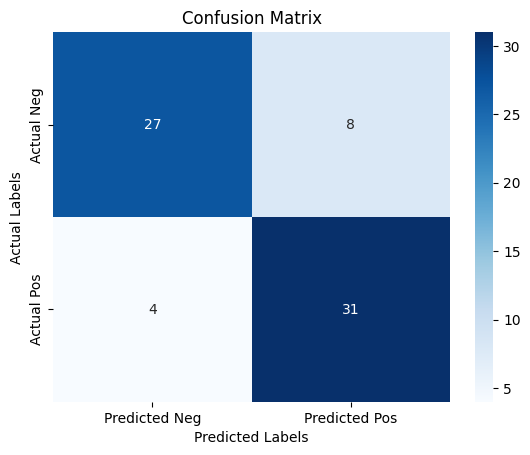

In [37]:
conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Neg', 'Predicted Pos'], yticklabels=['Actual Neg', 'Actual Pos'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix')
plt.show()

In [38]:
y_prob = tpot.predict_proba(X_test)[:, 1]  # get the probability of the positive class
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")

ROC-AUC Score: 0.95


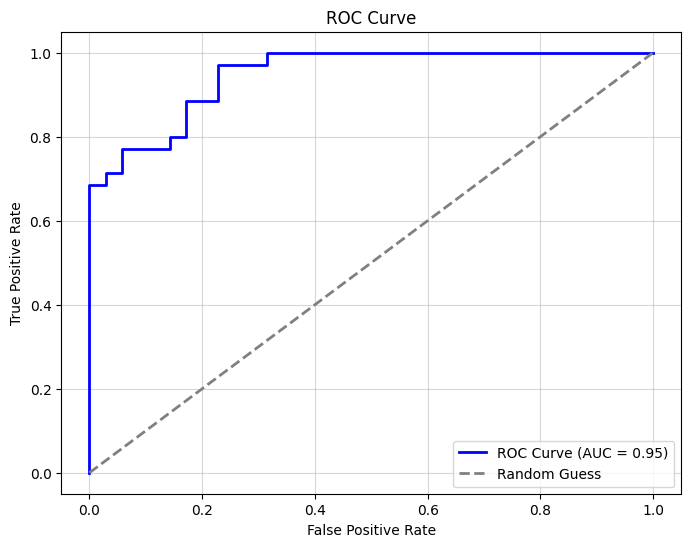

In [39]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.5)
plt.show()

### Comparing Model Performance
Now I execute the function I previously defined to be able to compare the different models. 

In [40]:
comparison_table = display_performance_comparison()

Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score
2        Random Forest  0.857143   0.857143  0.857143  0.857143
4                  MLP  0.828571   0.832920  0.828571  0.828010
0  Logistic Regression  0.714286   0.714988  0.714286  0.714052
1                  SVM  0.714286   0.742831  0.714286  0.705635
3                  MLP  0.600000   0.600328  0.600000  0.599673
